## Step 1: Import Libraries & Dataset 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [57]:
# Load dataset
df = pd.read_csv("C:\\Users\\vansh\\Downloads\\heart.csv")

# Preview data
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Step 2: Data Analysis

In [58]:
# Dataset info
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (918, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
print("\nStatistics:")
print(df.describe())


Statistics:
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


In [59]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [60]:
print("\nCorrelation Matrix:")
corr = df.select_dtypes(include=[np.number]).corr()
print(corr)


Correlation Matrix:
                   Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak  \
Age           1.000000   0.254399    -0.095282   0.198039 -0.382045  0.258612   
RestingBP     0.254399   1.000000     0.100893   0.070193 -0.112135  0.164803   
Cholesterol  -0.095282   0.100893     1.000000  -0.260974  0.235792  0.050148   
FastingBS     0.198039   0.070193    -0.260974   1.000000 -0.131438  0.052698   
MaxHR        -0.382045  -0.112135     0.235792  -0.131438  1.000000 -0.160691   
Oldpeak       0.258612   0.164803     0.050148   0.052698 -0.160691  1.000000   
HeartDisease  0.282039   0.107589    -0.232741   0.267291 -0.400421  0.403951   

              HeartDisease  
Age               0.282039  
RestingBP         0.107589  
Cholesterol      -0.232741  
FastingBS         0.267291  
MaxHR            -0.400421  
Oldpeak           0.403951  
HeartDisease      1.000000  


## Step 3: Data Visualization

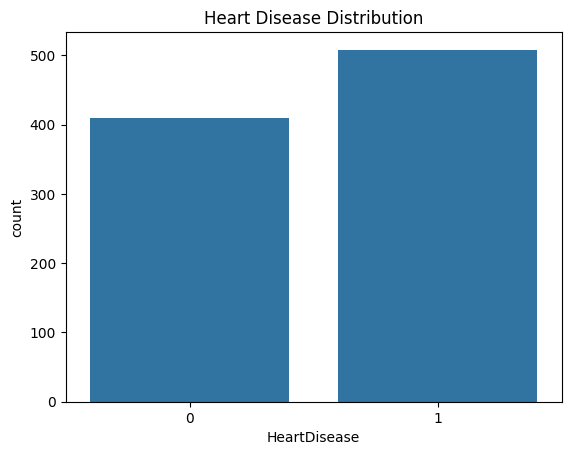

In [61]:
# a. Countplot of HeartDisease variable
sns.countplot(x='HeartDisease', data=df)
plt.title('Heart Disease Distribution')
plt.show()

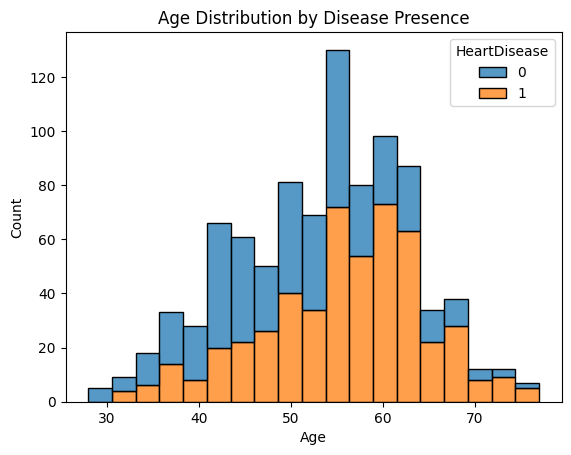

In [11]:
# b. Age vs Disease
sns.histplot(data=df, x='Age', hue='HeartDisease', multiple='stack')
plt.title('Age Distribution by Disease Presence')
plt.show()

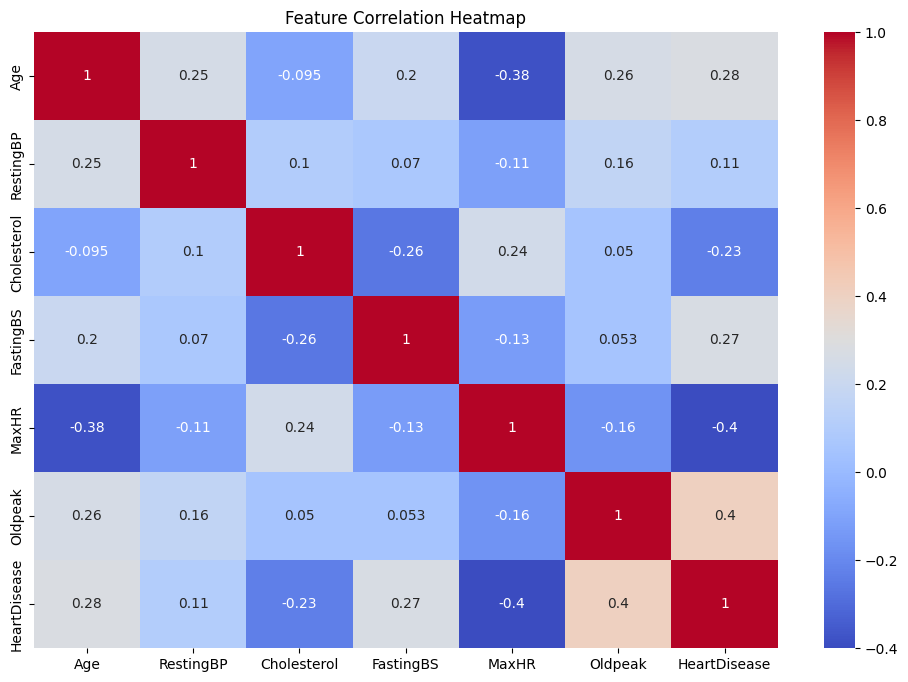

In [62]:
# c. Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Missing Values per Column:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR        

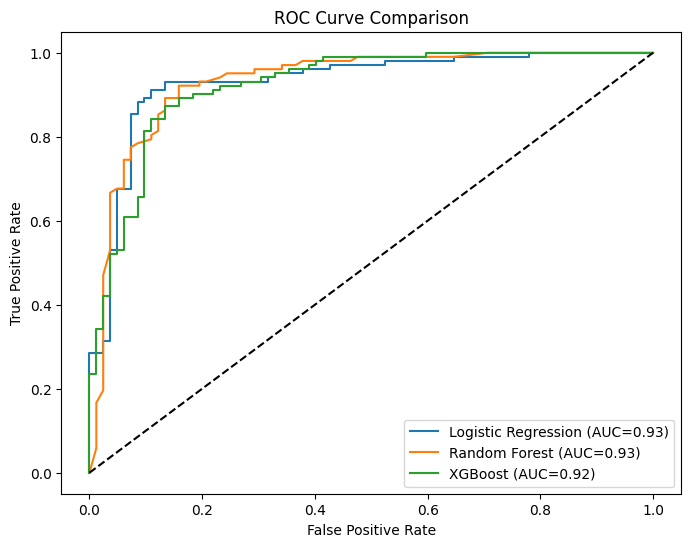

Logistic Regression Cross-Validation Accuracy: 0.831
Random Forest Cross-Validation Accuracy: 0.817
XGBoost Cross-Validation Accuracy: 0.814


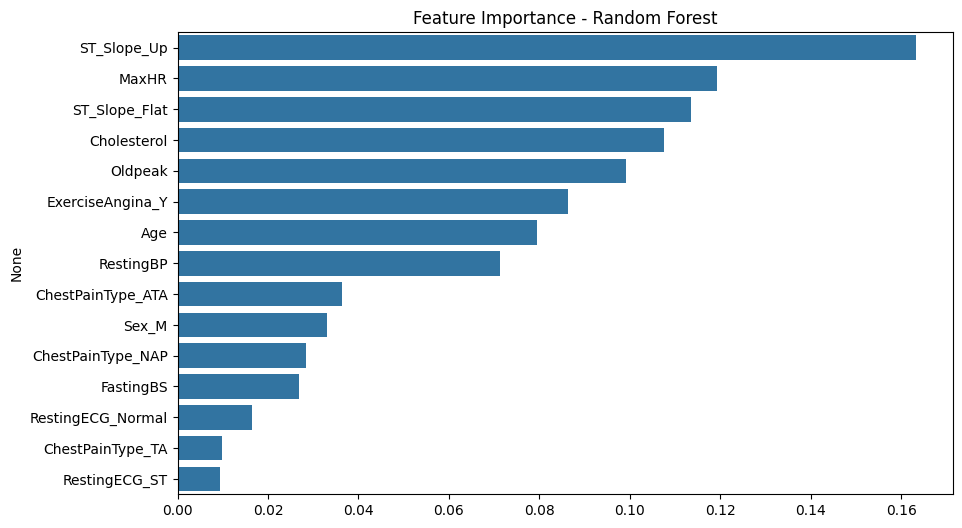


✅ Results saved to 'heart_prediction_results.csv' for Tableau visualization!

🔍 Example Prediction:
Input: {'Age': 40, 'Sex': 'M', 'ChestPainType': 'ATA', 'RestingBP': 140, 'Cholesterol': 289, 'FastingBS': 0, 'RestingECG': 'Normal', 'MaxHR': 172, 'ExerciseAngina': 'N', 'Oldpeak': 0.0, 'ST_Slope': 'Up'}
Prediction: No Heart Disease

 Program Finished Successfully!


In [ ]:
# ===============================================
# STEP 4: DATA UNDERSTANDING
# ===============================================
print("\nDataset Info:")
print(df.info())

print("\nMissing Values per Column:\n", df.isnull().sum())

print("\nBasic Statistics:\n", df.describe())

# ===============================================
# STEP 5: FEATURE SELECTION & PREPROCESSING
# ===============================================
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# Split dataset (use original indices for train/test split)
X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    X.index, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_encoded.loc[X_train_idx]
X_test = X_encoded.loc[X_test_idx]

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData Preprocessing Completed Successfully!")

# ===============================================
# STEP 6: MODEL TRAINING
# ===============================================

# ---- Logistic Regression ----
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# ---- Random Forest ----
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# ---- XGBoost ----
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

# ===============================================
# STEP 7: MODEL EVALUATION
# ===============================================

def evaluate_model(name, y_test, y_pred):
    print(f"\n==== {name} Model Evaluation ====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Evaluate all models
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)

# ===============================================
# STEP 8: ROC CURVE COMPARISON
# ===============================================
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": xgb
}

plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("roc_curve_comparison.png")
plt.show()

# ===============================================
# STEP 9: CROSS VALIDATION
# ===============================================
for name, model in models.items():
    scores = cross_val_score(model, X_encoded, y, cv=5)
    print(f"{name} Cross-Validation Accuracy: {scores.mean():.3f}")

# ===============================================
# STEP 10: FEATURE IMPORTANCE
# ===============================================
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X_encoded.columns[indices])
plt.title("Feature Importance - Random Forest")
plt.savefig("feature_importance.png")
plt.show()

# ===============================================
# STEP 11: SAVE RESULTS FOR TABLEAU
# ===============================================
results_df = pd.DataFrame({
    "Actual": y_test,
    "LogisticRegression_Pred": y_pred_lr,
    "RandomForest_Pred": y_pred_rf,
    "XGBoost_Pred": y_pred_xgb
})

results_df.to_csv("heart_prediction_results.csv", index=False)
print("\n Results saved to 'heart_prediction_results.csv' for Tableau visualization!")

# ===============================================
# STEP 12: PREDICTION SYSTEM (USER INPUT)
# ===============================================
def predict_heart_disease(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    input_encoded = pd.get_dummies(input_df, drop_first=True)
    # Align columns with training data
    input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)
    scaled_input = scaler.transform(input_encoded)
    prediction = log_reg.predict(scaled_input)
    return "Heart Disease Detected" if prediction[0] == 1 else "No Heart Disease"

print("\n Example Prediction:")
example_data = X.iloc[0].to_dict()
print("Input:", example_data)
print("Prediction:", predict_heart_disease(example_data))

print("\n Program Finished Successfully!")



